## Import and load the data

In [1]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import h5py

def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

## Data exploration
Trying to figure out the data first since we never worked with MEG data before

In [3]:
DATASET_PATH = "/Users/stijnroos/VisualStudio/DL_data/"

RAW_FOLDERS = {
    "intra_train": os.path.join(DATASET_PATH, "Intra", "train"),
    "intra_test": os.path.join(DATASET_PATH, "Intra", "test"),
    "cross_train": os.path.join(DATASET_PATH, "Cross", "train"),
    "cross_test1": os.path.join(DATASET_PATH, "Cross", "test1"),
    "cross_test2": os.path.join(DATASET_PATH, "Cross", "test2"),
    "cross_test3": os.path.join(DATASET_PATH, "Cross", "test3"),
}

def parse_filename(path):
    name = os.path.basename(path).replace(".h5", "")
    parts = name.split("_")
    subject = parts[-2]
    chunk = int(parts[-1])
    task = "_".join(parts[:-2])
    return task, subject, chunk

rows = []

for split_name, folder in RAW_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))
    for file in files:
        task, subject, chunk = parse_filename(file)
        rows.append({
            "split": split_name,
            "file": os.path.basename(file),
            "task": task,
            "subject": subject,
            "chunk": chunk,
            "path": file
        })

df_files = pd.DataFrame(rows)
df_files.head(10)

,split,file,task,subject,chunk,path
0,intra_train,rest_105923_1.h5,rest,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
1,intra_train,rest_105923_2.h5,rest,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
2,intra_train,rest_105923_3.h5,rest,105923,3,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
3,intra_train,rest_105923_4.h5,rest,105923,4,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
4,intra_train,rest_105923_5.h5,rest,105923,5,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
5,intra_train,rest_105923_6.h5,rest,105923,6,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
6,intra_train,rest_105923_7.h5,rest,105923,7,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
7,intra_train,rest_105923_8.h5,rest,105923,8,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
8,intra_train,task_motor_105923_1.h5,task_motor,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
9,intra_train,task_motor_105923_2.h5,task_motor,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...


In [4]:
print("Total files:", len(df_files))
display(df_files.groupby(["split", "task"]).size().unstack(fill_value=0))
display(df_files.groupby(["split", "subject"]).size().unstack(fill_value=0))
display(df_files.groupby(["split", "task", "subject"]).size())

Total files: 152


task,rest,task_motor,task_story_math,task_working_memory
split,,,,
cross_test1,4,4,4,4
cross_test2,4,4,4,4
cross_test3,4,4,4,4
cross_train,16,16,16,16
intra_test,2,2,2,2
intra_train,8,8,8,8


subject,105923,113922,162935,164636,707749,725751,735148
split,,,,,,,
cross_test1,0,0,16,0,0,0,0
cross_test2,0,0,0,0,16,0,0
cross_test3,0,0,0,0,0,8,8
cross_train,0,32,0,32,0,0,0
intra_test,8,0,0,0,0,0,0
intra_train,32,0,0,0,0,0,0


split        task                 subject
cross_test1  rest                 162935     4
             task_motor           162935     4
             task_story_math      162935     4
             task_working_memory  162935     4
cross_test2  rest                 707749     4
             task_motor           707749     4
             task_story_math      707749     4
             task_working_memory  707749     4
cross_test3  rest                 725751     2
                                  735148     2
             task_motor           725751     2
                                  735148     2
             task_story_math      725751     2
                                  735148     2
             task_working_memory  725751     2
                                  735148     2
cross_train  rest                 113922     8
                                  164636     8
             task_motor           113922     8
                                  164636     8
             task_

In [5]:
def read_h5_file(filepath):
    with h5py.File(filepath, "r") as f:
        keys = list(f.keys())
        if len(keys) != 1:
            raise ValueError(f"Expected one dataset, found {keys}")
        dataset_name = keys[0]
        X = f[dataset_name][()]
    return X, dataset_name

In [6]:
sample_file = df_files.iloc[0]["path"]

X, dataset_name = read_h5_file(sample_file)

print("File:", os.path.basename(sample_file))
print("Dataset name:", dataset_name)

print("Shape:", X.shape)
print("Dtype:", X.dtype)

print("\nStatistics:")
print("Min:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())
print("Std:", X.std())

print("\nMemory usage (MB):")
print(X.nbytes / 1024**2)

File: rest_105923_1.h5
Dataset name: rest_105923
Shape: (248, 35624)
Dtype: float64

Statistics:
Min: -2.788253829211218e-11
Max: 1.3240070498299339e-11
Mean: 4.094354904508632e-14
Std: 4.909138310890537e-12

Memory usage (MB):
67.40380859375


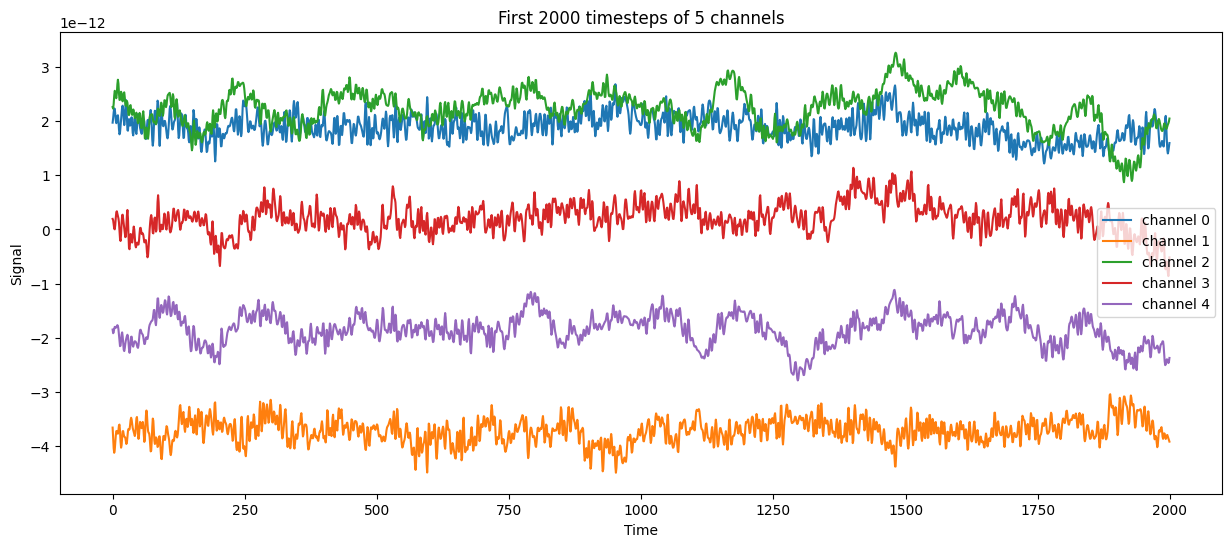

In [7]:
plt.figure(figsize=(15, 6))

for i in range(5):
    plt.plot(X[i, :2000], label=f"channel {i}")

plt.title("First 2000 timesteps of 5 channels")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.show()

In [8]:
summary_rows = []

for _, row in df_files.iterrows():
    X, key = read_h5_file(row["path"])
    summary_rows.append({
        "split": row["split"],
        "task": row["task"],
        "subject": row["subject"],
        "file": row["file"],
        "key": key,
        "shape": X.shape,
        "dtype": str(X.dtype),
        "min": X.min(),
        "max": X.max(),
        "mean": X.mean(),
        "std": X.std(),
        "memory_mb": X.nbytes / 1024**2
    })

df_summary = pd.DataFrame(summary_rows)

print("Unique shapes:", df_summary["shape"].unique())
print("Unique dtypes:", df_summary["dtype"].unique())
print("Total memory if fully loaded:", df_summary["memory_mb"].sum(), "MB")

display(df_summary.groupby(["split", "task"])[["min", "max", "mean", "std"]].mean())

Unique shapes: [(248, 35624)]
Unique dtypes: ['float64']
Total memory if fully loaded: 10245.37890625 MB


min           max          mean  \
split       task                                                            
cross_test1 rest                -2.417695e-11  3.281256e-11  1.403908e-12   
            task_motor          -1.464510e-10  7.328023e-12 -7.675851e-13   
            task_story_math     -3.735773e-11  8.140740e-12 -5.553890e-14   
            task_working_memory -2.269747e-10  2.222397e-11  1.871512e-13   
cross_test2 rest                -2.875010e-11  4.002255e-11  9.717947e-13   
            task_motor          -3.794924e-10  2.322366e-11 -1.191946e-12   
            task_story_math     -2.524722e-10  5.578384e-11 -2.131746e-12   
            task_working_memory -1.533678e-10  3.495876e-11 -1.475140e-12   
cross_test3 rest                -3.125810e-11  4.289565e-11  1.283255e-12   
            task_motor          -1.299066e-10  9.812833e-12  5.323511e-13   
            task_story_math     -2.769507e-10  2.542496e-11 -1.071959e-12   
            task_working_memory -2.144747e-10  1.117858e-11 -1.130372e-12   
cross_train rest                -4.085917e-11  3.935921e-11  7.736768e-13   
            task_motor          -1.719962e-10  1.275309e-11 -1.008501e-13   
            task_story_math     -4.938406e-11  5.351631e-12  7.213017e-14   
            task_working_memory -2.197490e-10  8.873976e-12 -4.459452e-13   
intra_test  rest                -4.838124e-11  3.469089e-11  3.040459e-12   
            task_motor          -3.375209e-10  1.352729e-11 -1.250118e-12   
            task_story_math     -1.157972e-10  9.403583e-12  6.512599e-13   
            task_working_memory -1.721721e-10  1.897677e-11  1.838611e-12   
intra_train rest                -4.434478e-11  2.221766e-11  1.442381e-12   
            task_motor          -1.959208e-10  9.899276e-12 -3.933353e-13   
            task_story_math     -9.156647e-11  9.634018e-12  1.064854e-12   
            task_working_memory -1.371398e-10  1.494194e-11  1.134688e-12   

                                          std  
split       task                               
cross_test1 rest                 4.249768e-12  
            task_motor           8.923254e-12  
            task_story_math      2.304083e-12  
            task_working_memory  1.387564e-11  
cross_test2 rest                 1.008465e-11  
            task_motor           2.413086e-11  
            task_story_math      1.618756e-11  
            task_working_memory  1.138280e-11  
cross_test3 rest                 9.217902e-12  
            task_motor           8.063570e-12  
            task_story_math      1.731163e-11  
            task_working_memory  1.308854e-11  
cross_train rest                 6.364122e-12  
            task_motor           1.043408e-11  
            task_story_math      3.122570e-12  
            task_working_memory  1.343616e-11  
intra_test  rest                 1.341991e-11  
            task_motor           2.068997e-11  
            task_story_math      7.561008e-12  
            task_working_memory  1.134360e-11  
intra_train rest                 8.654158e-12  
            task_motor           1.171845e-11  
            task_story_math      5.972657e-12  
            task_working_memory  8.728497e-12

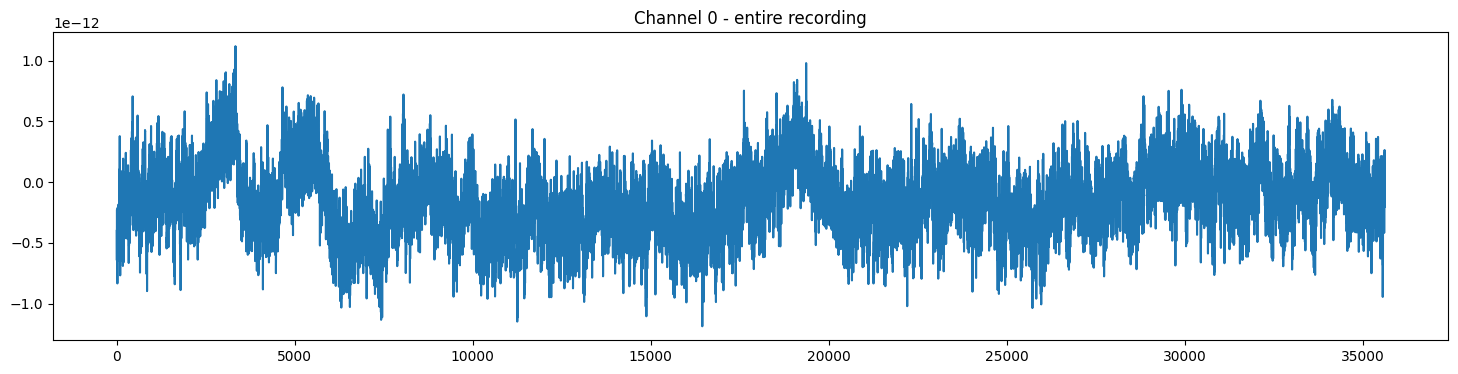

In [9]:
channel = 0

plt.figure(figsize=(18,4))
plt.plot(X[channel])
plt.title(f"Channel {channel} - entire recording")
plt.show()

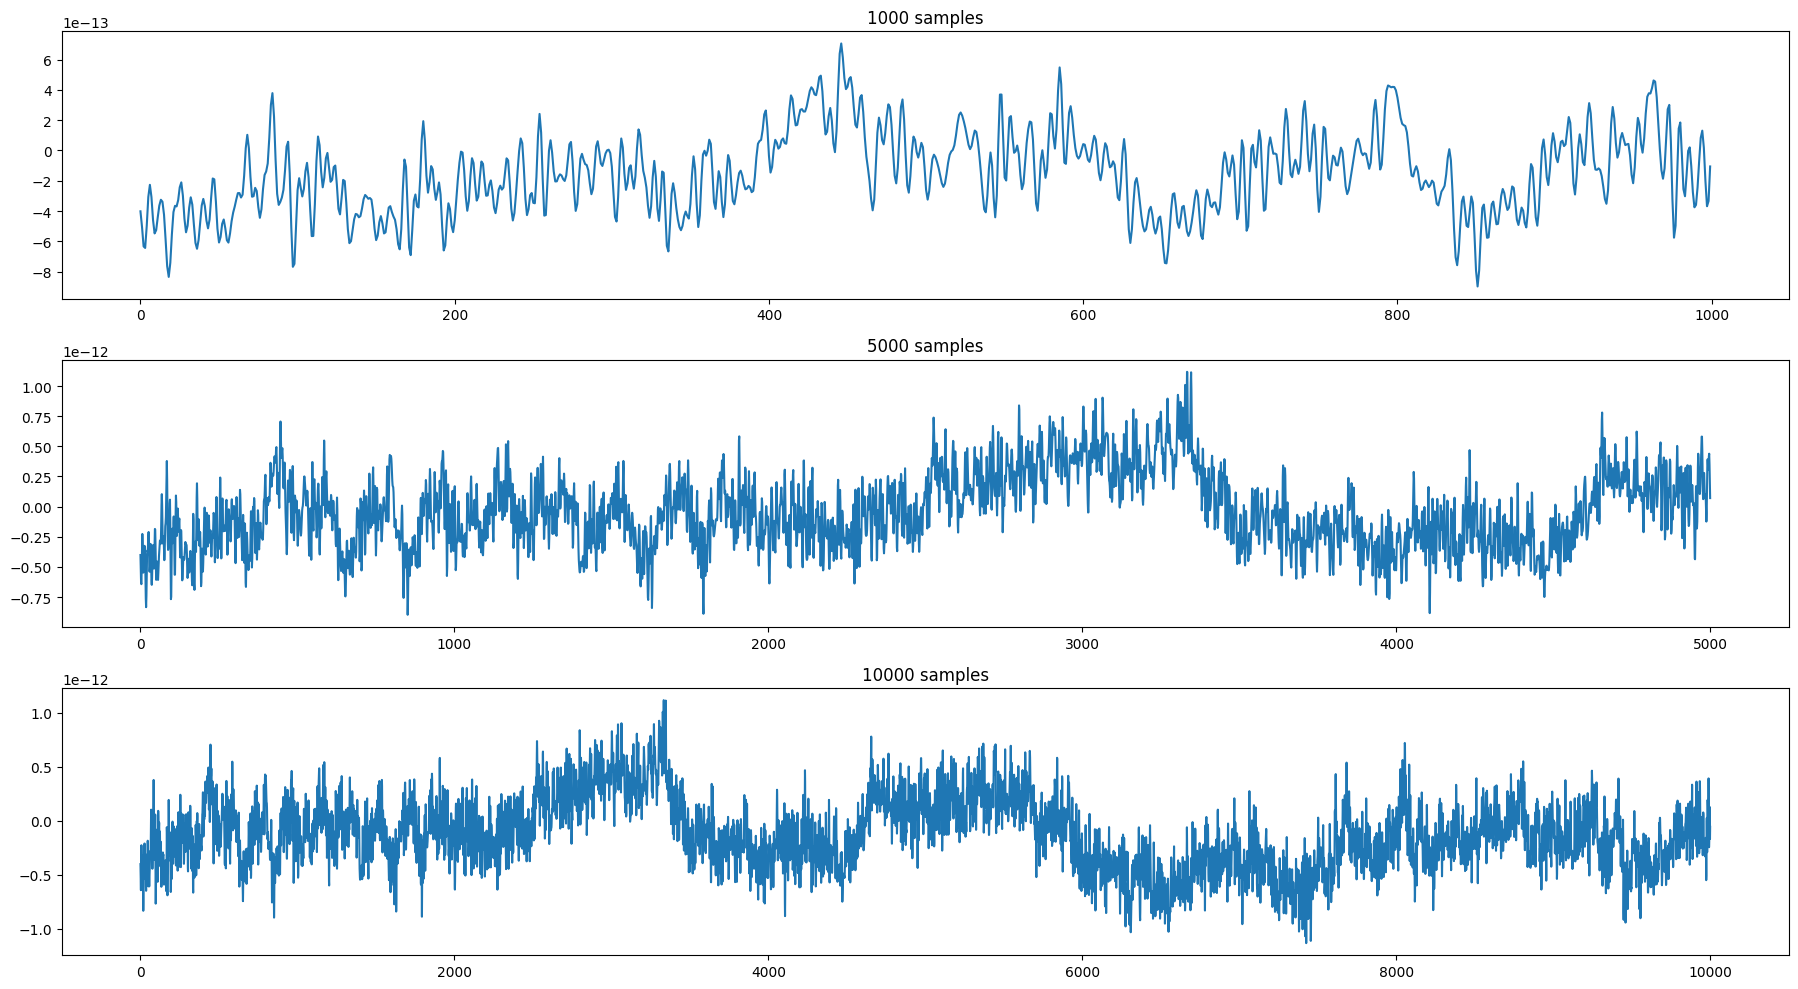

In [10]:
channel = 0

fig, axes = plt.subplots(3, 1, figsize=(18,10))

axes[0].plot(X[channel, :1000])
axes[0].set_title("1000 samples")

axes[1].plot(X[channel, :5000])
axes[1].set_title("5000 samples")

axes[2].plot(X[channel, :10000])
axes[2].set_title("10000 samples")

plt.tight_layout()
plt.show()

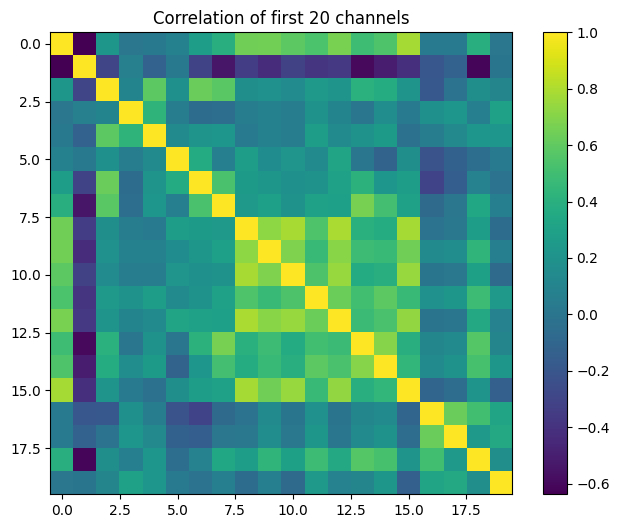

In [11]:
corr = np.corrcoef(X[:20])

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation of first 20 channels")
plt.show()

In [12]:
sample_rate = 2034
duration = X.shape[1] / sample_rate

print("Duration (seconds):", duration)

for factor in [2, 4, 8]:
    print(
        f"factor={factor:2d} -> "
        f"{X.shape[1]//factor} timesteps"
    )

Duration (seconds): 17.514257620452312
factor= 2 -> 17812 timesteps
factor= 4 -> 8906 timesteps
factor= 8 -> 4453 timesteps


Original shape: (248, 35624)
Downsampled shape: (248, 8906)


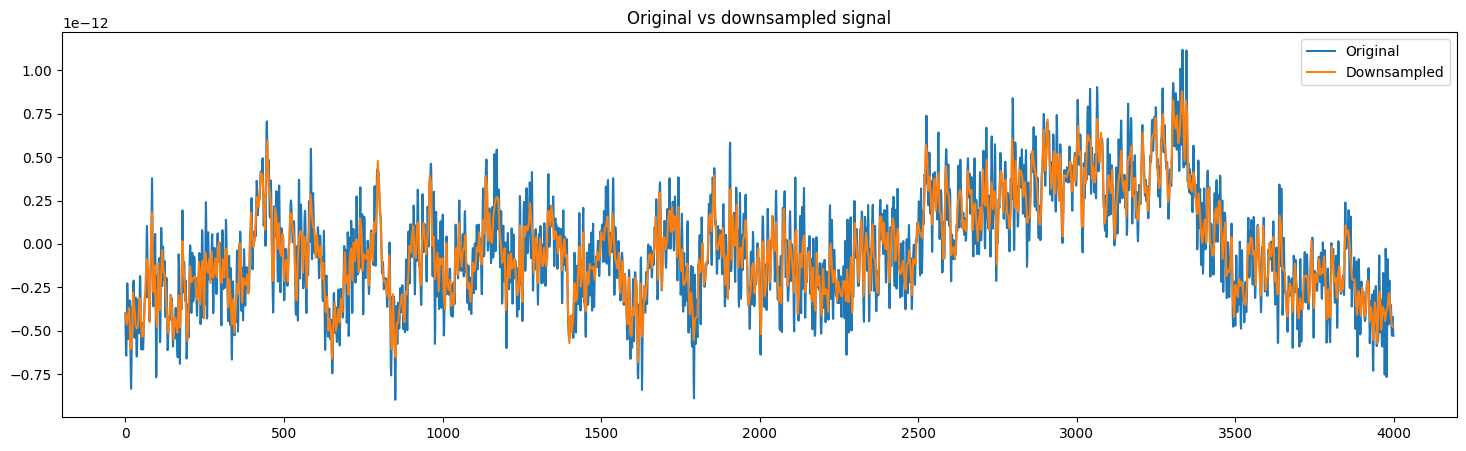

Raw stats:
-1.1668739564185331e-12 1.3227933298550109e-11 -2.1524897142466415e-10 1.1000712493713927e-11

Downsampled stats:
-1.1535319555711553e-12 1.3075787398925649e-11 -2.1242607852631696e-10 1.0695932035968406e-11


In [13]:
from scipy.signal import decimate

# try factor 4 downsampling and plot the difference
factor = 4
channel = 0

X_down = decimate(X, q=factor, axis=1, zero_phase=True)

print("Original shape:", X.shape)
print("Downsampled shape:", X_down.shape)

plt.figure(figsize=(18, 5))
plt.plot(X[channel, :4000], label="Original")
plt.plot(
    np.arange(0, 4000, factor),
    X_down[channel, :4000 // factor],
    label="Downsampled",
)
plt.title("Original vs downsampled signal")
plt.legend()
plt.show()

print("Raw stats:")
print(X.mean(), X.std(), X.min(), X.max())

print("\nDownsampled stats:")
print(X_down.mean(), X_down.std(), X_down.min(), X_down.max())

----
## Data preprocessing

1. Mulitply data by 10^15
2. Downsample data using decimate
3. z-score normalise

Do this for the intra and the cross datasets and make overlapping windows

In [14]:
def preprocess_meg(X, downsample_factor=4, eps=1e-12):
    # Convert Tesla-scale values to femtoTesla-like scale
    X = X * 1e15

    # Downsample over time axis
    X = decimate(X, q=downsample_factor, axis=1, zero_phase=True)

    # Z-score per channel within this recording
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    X = (X - mean) / (std + eps)

    return X.astype(np.float32)


def make_windows(X, window_size=512, stride=256):
    windows = []

    for start in range(0, X.shape[1] - window_size + 1, stride):
        end = start + window_size
        windows.append(X[:, start:end])

    return np.stack(windows)

In [15]:
# new mean should be close to zero and the std close to 1

X_processed = preprocess_meg(X, downsample_factor=4)
windows = make_windows(X_processed, window_size=512, stride=256)

print("Processed shape:", X_processed.shape)
print("Windows shape:", windows.shape)
print("Processed mean:", X_processed.mean())
print("Processed std:", X_processed.std())
print("Per-channel mean range:", X_processed.mean(axis=1).min(), X_processed.mean(axis=1).max())
print("Per-channel std range:", X_processed.std(axis=1).min(), X_processed.std(axis=1).max())
print("One window shape:", windows[0].shape)

Processed shape: (248, 8906)
Windows shape: (33, 248, 512)
Processed mean: 8.0138957e-10
Processed std: 1.0
Per-channel mean range: -2.741305e-08 2.741305e-08
Per-channel std range: 0.99999994 1.0
One window shape: (248, 512)


In [16]:
TASK_TO_LABEL = {
    "rest": 0,
    "task_story_math": 1,
    "task_working_memory": 2,
    "task_motor": 3,
}

LABEL_TO_TASK = {v: k for k, v in TASK_TO_LABEL.items()}

print(TASK_TO_LABEL)

{'rest': 0, 'task_story_math': 1, 'task_working_memory': 2, 'task_motor': 3}


In [17]:
def load_windowed_split(df_split, window_size=512, stride=256, downsample_factor=4):
    X_all = []
    y_all = []
    file_all = []

    for _, row in df_split.iterrows():
        X_raw, _ = read_h5_file(row["path"])
        X_processed = preprocess_meg(X_raw, downsample_factor=downsample_factor)
        windows = make_windows(X_processed, window_size=window_size, stride=stride)

        label = TASK_TO_LABEL[row["task"]]

        X_all.append(windows)
        y_all.extend([label] * len(windows))
        file_all.extend([row["file"]] * len(windows))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.array(y_all, dtype=np.int64)
    file_all = np.array(file_all)

    return X_all, y_all, file_all

#### Apply to Intra set

In [18]:
df_intra_train = df_files[df_files["split"] == "intra_train"].reset_index(drop=True)
df_intra_test = df_files[df_files["split"] == "intra_test"].reset_index(drop=True)

X_intra_train, y_intra_train, files_intra_train = load_windowed_split(df_intra_train)
X_intra_test, y_intra_test, files_intra_test = load_windowed_split(df_intra_test)

print("X_intra_train:", X_intra_train.shape)
print("y_intra_train:", y_intra_train.shape)
print("X_intra_test:", X_intra_test.shape)
print("y_intra_test:", y_intra_test.shape)

print("Train class counts:", np.bincount(y_intra_train))
print("Test class counts:", np.bincount(y_intra_test))

X_intra_train: (1056, 248, 512)
y_intra_train: (1056,)
X_intra_test: (264, 248, 512)
y_intra_test: (264,)
Train class counts: [264 264 264 264]
Test class counts: [66 66 66 66]


#### Apply to Cross set

In [19]:
df_cross_train = df_files[df_files["split"] == "cross_train"].reset_index(drop=True)
df_cross_test1 = df_files[df_files["split"] == "cross_test1"].reset_index(drop=True)
df_cross_test2 = df_files[df_files["split"] == "cross_test2"].reset_index(drop=True)
df_cross_test3 = df_files[df_files["split"] == "cross_test3"].reset_index(drop=True)

X_cross_train, y_cross_train, files_cross_train = load_windowed_split(df_cross_train)
X_cross_test1, y_cross_test1, files_cross_test1 = load_windowed_split(df_cross_test1)
X_cross_test2, y_cross_test2, files_cross_test2 = load_windowed_split(df_cross_test2)
X_cross_test3, y_cross_test3, files_cross_test3 = load_windowed_split(df_cross_test3)

print("X_cross_train:", X_cross_train.shape)
print("X_cross_test1:", X_cross_test1.shape)
print("X_cross_test2:", X_cross_test2.shape)
print("X_cross_test3:", X_cross_test3.shape)

print("Train class counts:", np.bincount(y_cross_train))
print("Test1 class counts:", np.bincount(y_cross_test1))
print("Test2 class counts:", np.bincount(y_cross_test2))
print("Test3 class counts:", np.bincount(y_cross_test3))

X_cross_train: (2112, 248, 512)
X_cross_test1: (528, 248, 512)
X_cross_test2: (528, 248, 512)
X_cross_test3: (528, 248, 512)
Train class counts: [528 528 528 528]
Test1 class counts: [132 132 132 132]
Test2 class counts: [132 132 132 132]
Test3 class counts: [132 132 132 132]


---
## Model training

#### Setup model

In [20]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X_intra_train,
        y_intra_train,
        groups=files_intra_train
    )
)

X_train = X_intra_train[train_idx]
y_train = y_intra_train[train_idx]

X_val = X_intra_train[val_idx]
y_val = y_intra_train[val_idx]

print("Train:", X_train.shape)
print("Val:", X_val.shape)

print("Train files:", len(np.unique(files_intra_train[train_idx])))
print("Val files:", len(np.unique(files_intra_train[val_idx])))

Train: (825, 248, 512)
Val: (231, 248, 512)
Train files: 25
Val files: 7


In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else 
                      "cuda" if torch.cuda.is_available() else 
                      "cpu")

print("Using device:", device)

class MEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

batch_size = 32


train_loader = DataLoader(
    MEGWindowDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    MEGWindowDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    MEGWindowDataset(X_intra_test, y_intra_test),
    batch_size=batch_size,
    shuffle=False
)

Using device: mps


In [22]:
class MEG1DCNN(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
model = MEG1DCNN().to(device)

xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    out = model(xb)

print("Input batch:", xb.shape)
print("Output batch:", out.shape)

Input batch: torch.Size([32, 248, 512])
Output batch: torch.Size([32, 4])


#### Train Intra-subject model

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

In [25]:
model = MEG1DCNN(dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0
best_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Best validation accuracy:", best_val_acc)
print("Intra-subject test accuracy:", test_acc)

Epoch 01/30 | train loss 1.1578 acc 0.479 | val loss 1.4726 acc 0.143
Epoch 02/30 | train loss 0.8752 acc 0.623 | val loss 1.2557 acc 0.251
Epoch 03/30 | train loss 0.6548 acc 0.745 | val loss 1.2857 acc 0.398
Epoch 04/30 | train loss 0.5018 acc 0.806 | val loss 1.3562 acc 0.303
Epoch 05/30 | train loss 0.3458 acc 0.875 | val loss 1.0788 acc 0.519
Epoch 06/30 | train loss 0.2923 acc 0.895 | val loss 1.5438 acc 0.407
Epoch 07/30 | train loss 0.2248 acc 0.925 | val loss 1.5136 acc 0.411
Epoch 08/30 | train loss 0.1304 acc 0.960 | val loss 1.3573 acc 0.481
Epoch 09/30 | train loss 0.0916 acc 0.978 | val loss 1.4201 acc 0.519
Epoch 10/30 | train loss 0.1376 acc 0.953 | val loss 2.1238 acc 0.424
Epoch 11/30 | train loss 0.1305 acc 0.953 | val loss 1.5235 acc 0.567
Epoch 12/30 | train loss 0.1221 acc 0.964 | val loss 1.7878 acc 0.468
Epoch 13/30 | train loss 0.0894 acc 0.968 | val loss 1.5081 acc 0.511
Epoch 14/30 | train loss 0.0545 acc 0.977 | val loss 1.6258 acc 0.506
Epoch 15/30 | train 

#### Add smaller model, likely overfitting

In [26]:
class SmallMEG1DCNN(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [27]:
model = SmallMEG1DCNN(dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)

num_epochs = 40
best_val_acc = 0
best_state = None

history_small = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_small["train_loss"].append(train_loss)
    history_small["train_acc"].append(train_acc)
    history_small["val_loss"].append(val_loss)
    history_small["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Best validation accuracy:", best_val_acc)
print("Intra-subject test accuracy:", test_acc)

Epoch 01/40 | train loss 1.2183 acc 0.434 | val loss 1.3784 acc 0.212
Epoch 02/40 | train loss 0.8977 acc 0.656 | val loss 1.3361 acc 0.286
Epoch 03/40 | train loss 0.7417 acc 0.755 | val loss 1.2356 acc 0.364
Epoch 04/40 | train loss 0.5760 acc 0.835 | val loss 1.4580 acc 0.290
Epoch 05/40 | train loss 0.4233 acc 0.915 | val loss 1.2541 acc 0.394
Epoch 06/40 | train loss 0.3401 acc 0.933 | val loss 1.2882 acc 0.381
Epoch 07/40 | train loss 0.2576 acc 0.960 | val loss 1.1405 acc 0.519
Epoch 08/40 | train loss 0.2105 acc 0.959 | val loss 1.1205 acc 0.515
Epoch 09/40 | train loss 0.1380 acc 0.988 | val loss 1.1785 acc 0.494
Epoch 10/40 | train loss 0.1184 acc 0.989 | val loss 1.0700 acc 0.506
Epoch 11/40 | train loss 0.0840 acc 0.998 | val loss 1.1249 acc 0.485
Epoch 12/40 | train loss 0.0915 acc 0.992 | val loss 1.0875 acc 0.537
Epoch 13/40 | train loss 0.1086 acc 0.982 | val loss 1.2557 acc 0.537
Epoch 14/40 | train loss 0.0683 acc 0.998 | val loss 1.0489 acc 0.602
Epoch 15/40 | train 

#### Cross subject training

In [28]:
# Cross-subject grouped train/validation split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X_cross_train,
        y_cross_train,
        groups=files_cross_train
    )
)

X_train_cross = X_cross_train[train_idx]
y_train_cross = y_cross_train[train_idx]

X_val_cross = X_cross_train[val_idx]
y_val_cross = y_cross_train[val_idx]

print("Cross train:", X_train_cross.shape)
print("Cross val:", X_val_cross.shape)
print("Train files:", len(np.unique(files_cross_train[train_idx])))
print("Val files:", len(np.unique(files_cross_train[val_idx])))

print("Train class counts:", np.bincount(y_train_cross))
print("Val class counts:", np.bincount(y_val_cross))

Cross train: (1683, 248, 512)
Cross val: (429, 248, 512)
Train files: 51
Val files: 13
Train class counts: [396 429 396 462]
Val class counts: [132  99 132  66]


In [29]:
batch_size = 32

cross_train_loader = DataLoader(
    MEGWindowDataset(X_train_cross, y_train_cross),
    batch_size=batch_size,
    shuffle=True
)

cross_val_loader = DataLoader(
    MEGWindowDataset(X_val_cross, y_val_cross),
    batch_size=batch_size,
    shuffle=False
)

cross_test1_loader = DataLoader(
    MEGWindowDataset(X_cross_test1, y_cross_test1),
    batch_size=batch_size,
    shuffle=False
)

cross_test2_loader = DataLoader(
    MEGWindowDataset(X_cross_test2, y_cross_test2),
    batch_size=batch_size,
    shuffle=False
)

cross_test3_loader = DataLoader(
    MEGWindowDataset(X_cross_test3, y_cross_test3),
    batch_size=batch_size,
    shuffle=False
)

In [30]:
# model_cross = MEG1DCNN(dropout=0.3).to(device)
model_cross = SmallMEG1DCNN(dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_cross.parameters(),
    lr=3e-4,
    weight_decay=1e-3
)

num_epochs = 40
best_val_acc = 0
best_state = None

history_cross = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_cross,
        cross_train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model_cross,
        cross_val_loader,
        criterion,
        device
    )

    history_cross["train_loss"].append(train_loss)
    history_cross["train_acc"].append(train_acc)
    history_cross["val_loss"].append(val_loss)
    history_cross["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_cross.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

model_cross.load_state_dict(best_state)

Epoch 01/40 | train loss 1.1744 acc 0.462 | val loss 1.0425 acc 0.510
Epoch 02/40 | train loss 0.8731 acc 0.660 | val loss 0.9599 acc 0.587
Epoch 03/40 | train loss 0.6620 acc 0.765 | val loss 0.9387 acc 0.643
Epoch 04/40 | train loss 0.5103 acc 0.849 | val loss 0.8222 acc 0.648
Epoch 05/40 | train loss 0.3815 acc 0.900 | val loss 0.7501 acc 0.704
Epoch 06/40 | train loss 0.2986 acc 0.914 | val loss 0.8024 acc 0.692
Epoch 07/40 | train loss 0.1969 acc 0.966 | val loss 0.7917 acc 0.716
Epoch 08/40 | train loss 0.1897 acc 0.957 | val loss 0.7852 acc 0.718
Epoch 09/40 | train loss 0.1503 acc 0.967 | val loss 0.6198 acc 0.748
Epoch 10/40 | train loss 0.1094 acc 0.981 | val loss 0.7466 acc 0.716
Epoch 11/40 | train loss 0.1552 acc 0.958 | val loss 0.6364 acc 0.762
Epoch 12/40 | train loss 0.0895 acc 0.983 | val loss 0.6373 acc 0.772
Epoch 13/40 | train loss 0.0873 acc 0.983 | val loss 0.5630 acc 0.797
Epoch 14/40 | train loss 0.0928 acc 0.982 | val loss 0.7672 acc 0.748
Epoch 15/40 | train 

<All keys matched successfully>

In [31]:
cross_test1_loss, cross_test1_acc = evaluate(
    model_cross,
    cross_test1_loader,
    criterion,
    device
)

cross_test2_loss, cross_test2_acc = evaluate(
    model_cross,
    cross_test2_loader,
    criterion,
    device
)

cross_test3_loss, cross_test3_acc = evaluate(
    model_cross,
    cross_test3_loader,
    criterion,
    device
)

print("Best cross validation accuracy:", best_val_acc)
print("Cross test1 accuracy:", cross_test1_acc)
print("Cross test2 accuracy:", cross_test2_acc)
print("Cross test3 accuracy:", cross_test3_acc)

print("\nMean cross-subject test accuracy:")
print(np.mean([cross_test1_acc, cross_test2_acc, cross_test3_acc]))

Best cross validation accuracy: 0.8251748251748252
Cross test1 accuracy: 0.4602272727272727
Cross test2 accuracy: 0.4678030303030303
Cross test3 accuracy: 0.5587121212121212

Mean cross-subject test accuracy:
0.4955808080808081


## Confusion matrices

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [LABEL_TO_TASK[i] for i in range(4)]
class_names

['rest', 'task_story_math', 'task_working_memory', 'task_motor']

<Figure size 800x600 with 0 Axes>

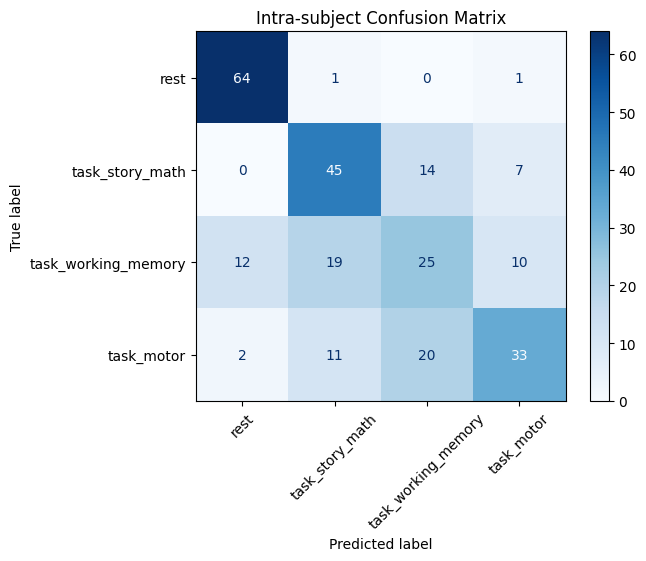

                     precision    recall  f1-score   support

               rest       0.82      0.97      0.89        66
    task_story_math       0.59      0.68      0.63        66
task_working_memory       0.42      0.38      0.40        66
         task_motor       0.65      0.50      0.56        66

           accuracy                           0.63       264
          macro avg       0.62      0.63      0.62       264
       weighted avg       0.62      0.63      0.62       264



In [33]:
y_true_intra, y_pred_intra = get_predictions(model, test_loader, device)

cm_intra = confusion_matrix(y_true_intra, y_pred_intra)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_intra,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Intra-subject Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    y_true_intra,
    y_pred_intra,
    target_names=class_names
))

<Figure size 800x600 with 0 Axes>

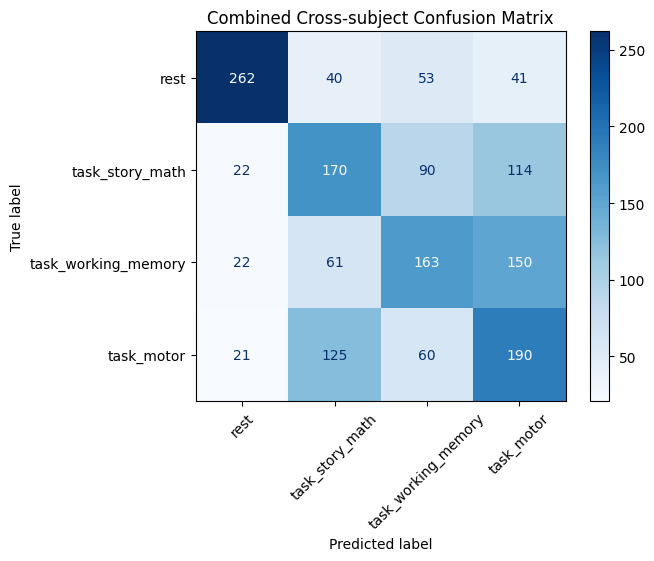

                     precision    recall  f1-score   support

               rest       0.80      0.66      0.72       396
    task_story_math       0.43      0.43      0.43       396
task_working_memory       0.45      0.41      0.43       396
         task_motor       0.38      0.48      0.43       396

           accuracy                           0.50      1584
          macro avg       0.51      0.50      0.50      1584
       weighted avg       0.51      0.50      0.50      1584



In [34]:
all_y_true_cross = []
all_y_pred_cross = []

for loader in [cross_test1_loader, cross_test2_loader, cross_test3_loader]:
    y_true_cross, y_pred_cross = get_predictions(model_cross, loader, device)
    all_y_true_cross.append(y_true_cross)
    all_y_pred_cross.append(y_pred_cross)

all_y_true_cross = np.concatenate(all_y_true_cross)
all_y_pred_cross = np.concatenate(all_y_pred_cross)

cm_cross_all = confusion_matrix(all_y_true_cross, all_y_pred_cross)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cross_all,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Combined Cross-subject Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    all_y_true_cross,
    all_y_pred_cross,
    target_names=class_names
))